In [22]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("weather_cleaned.csv")
print("Shape:", df.shape)
df.head()

Shape: (153586, 38)


,country,location_name,latitude,longitude,timezone,last_updated,temperature_celsius,condition_text,wind_kph,wind_degree,...,sunset,moonrise,moonset,moon_phase,moon_illumination,year,month,month_name,day_of_week,hour
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,2024-05-16 13:15:00,26.6,Partly Cloudy,13.3,338.0,...,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55.0,2024,5,May,Thursday,13
1,Albania,Tirana,41.33,19.82,Europe/Tirane,2024-05-16 10:45:00,19.0,Partly cloudy,11.2,320.0,...,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55.0,2024,5,May,Thursday,10
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,2024-05-16 09:45:00,23.0,Sunny,15.1,280.0,...,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55.0,2024,5,May,Thursday,9
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,2024-05-16 10:45:00,6.3,Light drizzle,11.9,215.0,...,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55.0,2024,5,May,Thursday,10
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,2024-05-16 09:45:00,26.0,Partly cloudy,13.0,150.0,...,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55.0,2024,5,May,Thursday,9


In [56]:
df["last_updated"] = pd.to_datetime(df["last_updated"])

In [57]:
df.info()

<class 'pandas.DataFrame'>
Index: 153577 entries, 0 to 153585
Data columns (total 38 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   country                       153577 non-null  str           
 1   location_name                 153577 non-null  str           
 2   latitude                      153577 non-null  float64       
 3   longitude                     153577 non-null  float64       
 4   timezone                      153577 non-null  str           
 5   last_updated                  153577 non-null  datetime64[us]
 6   temperature_celsius           153577 non-null  float64       
 7   condition_text                153577 non-null  str           
 8   wind_kph                      153577 non-null  float64       
 9   wind_degree                   153577 non-null  float64       
 10  wind_direction                153577 non-null  str           
 11  pressure_mb                  

## Overview Summary

In [24]:
overview = {
    "Observations": len(df),
    "Columns": df.shape[1],
    "Countries": df["country"].nunique(),
    "Unique location names": df["location_name"].nunique(),
    "Country-location pairs": (
        df[["country", "location_name"]]
        .drop_duplicates()
        .shape[0]
    ),
    "Start date": df["last_updated"].min(),
    "End date": df["last_updated"].max()
}

overview_df = pd.DataFrame(
    overview.items(),
    columns=["Metric", "Value"]
)

display(overview_df)

,Metric,Value
0,Observations,153586
1,Columns,38
2,Countries,186
3,Unique location names,217
4,Country-location pairs,219
5,Start date,2024-05-16 02:45:00
6,End date,2026-07-18 19:00:00


In [25]:
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percentage": (
        df.isna().mean() * 100
    ).round(4)
})

missing_summary = missing_summary[
    missing_summary["missing_count"] > 0
].sort_values(
    "missing_percentage",
    ascending=False
)

display(missing_summary)

,missing_count,missing_percentage
pressure_mb,2,0.0013
air_quality_PM10,2,0.0013
wind_kph,1,0.0007
temperature_celsius,1,0.0007
feels_like_celsius,1,0.0007
gust_kph,1,0.0007
air_quality_Carbon_Monoxide,1,0.0007
air_quality_Sulphur_dioxide,1,0.0007


In [26]:
df = df.dropna().copy()

In [27]:
print("Exact duplicate rows:", df.duplicated().sum())

location_time_duplicates = df.duplicated(
    subset=[
        "country",
        "location_name",
        "last_updated"
    ],
    keep=False
)

print(
    "Duplicate country-location-time rows:",
    location_time_duplicates.sum()
)

Exact duplicate rows: 0
Duplicate country-location-time rows: 2


In [28]:
display(
    df.loc[location_time_duplicates]
      .sort_values(
          ["country", "location_name", "last_updated"]
      )
)

,country,location_name,latitude,longitude,timezone,last_updated,temperature_celsius,condition_text,wind_kph,wind_degree,...,sunset,moonrise,moonset,moon_phase,moon_illumination,year,month,month_name,day_of_week,hour
124970,Thailand,Nan,18.7833,100.7833,Asia/Bangkok,2026-02-20 14:00:00,32.2,Partly Cloudy,4.3,178.0,...,06:19 PM,08:21 AM,08:58 PM,Waxing Crescent,6.0,2026,2,February,Friday,14
125006,Thailand,Nan,18.7833,100.7833,Asia/Bangkok,2026-02-20 14:00:00,32.2,Partly Cloudy,4.3,178.0,...,06:54 PM,09:05 AM,09:14 PM,Waxing Crescent,8.0,2026,2,February,Friday,14


In [29]:
# Remove duplicate country-location-time records
rows_before = len(df)

df = (
    df.drop_duplicates(
        subset=["country", "location_name", "last_updated"],
        keep="first"
    )
    .copy()
)

rows_after = len(df)

print(f"Rows removed: {rows_before - rows_after}")
print(f"Rows remaining: {rows_after:,}")

Rows removed: 1
Rows remaining: 153,577


In [30]:
# Convert the original timestamp column
df["last_updated"] = pd.to_datetime(
    df["last_updated"].astype(str).str.strip(),
    errors="coerce"
)

print("df timestamp type:", df["last_updated"].dtype)
print("Invalid timestamps:", df["last_updated"].isna().sum())

# Rebuild the summary
date_summary = (
    df.groupby(["country", "location_name"], dropna=False)
      .agg(
          first_observation=("last_updated", "min"),
          last_observation=("last_updated", "max"),
          observations=("last_updated", "size"),
          unique_dates=("last_updated", "nunique")
      )
      .reset_index()
)

# Force the grouped date columns to datetime as well
date_summary["first_observation"] = pd.to_datetime(
    date_summary["first_observation"],
    errors="coerce"
)

date_summary["last_observation"] = pd.to_datetime(
    date_summary["last_observation"],
    errors="coerce"
)

print(date_summary.dtypes)

date_summary["coverage_days"] = (
    date_summary["last_observation"]
    .sub(date_summary["first_observation"])
    .dt.days
)

display(date_summary.head())

df timestamp type: datetime64[us]
Invalid timestamps: 0
country                         str
location_name                   str
first_observation    datetime64[us]
last_observation     datetime64[us]
observations                  int64
unique_dates                  int64
dtype: object


,country,location_name,first_observation,last_observation,observations,unique_dates,coverage_days
0,Afghanistan,Kabul,2024-05-16 13:15:00,2026-07-18 10:15:00,791,791,792
1,Albania,Tirana,2024-05-16 10:45:00,2026-07-18 07:45:00,790,790,792
2,Algeria,Algiers,2024-05-16 09:45:00,2026-07-18 06:45:00,789,789,792
3,Andorra,Andorra La Vella,2024-05-16 10:45:00,2026-07-18 07:45:00,791,791,792
4,Angola,Luanda,2024-05-16 09:45:00,2026-07-18 07:00:00,791,791,792


# Descriptive Statistics

In [31]:
weather_columns = [
    "temperature_celsius",
    "feels_like_celsius",
    "humidity",
    "pressure_mb",
    "wind_kph",
    "gust_kph",
    "precip_mm",
    "visibility_km",
    "cloud",
    "uv_index"
]

available_weather_columns = [
    col for col in weather_columns
    if col in df.columns
]

descriptive_stats = (
    df[available_weather_columns]
    .describe()
    .T
)

descriptive_stats["median"] = (
    df[available_weather_columns]
    .median()
)

descriptive_stats["skewness"] = (
    df[available_weather_columns]
    .skew()
)

descriptive_stats["missing"] = (
    df[available_weather_columns]
    .isna()
    .sum()
)

descriptive_stats = descriptive_stats[
    [
        "count",
        "mean",
        "median",
        "std",
        "min",
        "25%",
        "50%",
        "75%",
        "max",
        "skewness",
        "missing"
    ]
]

display(descriptive_stats.round(2))

,count,mean,median,std,min,25%,50%,75%,max,skewness,missing
temperature_celsius,153577.0,21.36,23.7,9.48,-29.8,16.1,23.7,27.90,49.20,-0.83,0
feels_like_celsius,153577.0,22.14,25.0,11.38,-36.7,15.9,25.0,29.80,51.20,-0.78,0
humidity,153577.0,66.96,72.0,23.63,2.0,52.0,72.0,86.00,100.00,-0.67,0
pressure_mb,153577.0,1014.03,1014.0,6.89,947.0,1010.0,1014.0,1018.00,1080.00,0.04,0
wind_kph,153577.0,12.76,10.8,8.37,3.6,6.1,10.8,17.60,272.20,1.62,0
gust_kph,153577.0,18.07,15.1,11.22,3.6,10.0,15.1,24.00,279.40,1.48,0
precip_mm,153577.0,0.13,0.0,0.56,0.0,0.0,0.0,0.02,42.24,18.16,0
visibility_km,153577.0,9.51,10.0,2.68,0.0,10.0,10.0,10.00,32.00,1.05,0
cloud,153577.0,39.46,26.0,34.08,0.0,0.0,26.0,75.00,100.00,0.26,0
uv_index,153577.0,3.19,1.6,3.51,0.0,0.0,1.6,6.00,16.30,0.96,0


- The cleaned dataset contains 153,577 complete observations with no remaining missing values, indicating that the preprocessing stage successfully addressed data quality issues.
- The average air temperature is 21.36°C, with temperatures ranging from −29.8°C to 49.2°C, reflecting the wide variety of climates represented in the dataset.
- The average feels-like temperature (22.14°C) is slightly higher than the measured air temperature, highlighting the influence of atmospheric conditions such as humidity and wind.
- Relative humidity averages 66.96%, suggesting that many observations were recorded under moderately to highly humid conditions.
- Atmospheric pressure is centred around 1014 mb with very low skewness (0.04), indicating a stable and approximately symmetric distribution.
- Wind speed and gust speed exhibit positive skewness (1.62 and 1.48, respectively), showing that strong wind events occur relatively infrequently but contribute to a long upper tail.
- Precipitation displays an extremely right-skewed distribution (skewness = 18.16), with a median of 0 mm, indicating that most observations experienced no rainfall while a small number correspond to heavy precipitation events.
- Visibility is generally high, with a median of 10 km, although occasional low-visibility events are present.
- Cloud cover spans the full range from 0% to 100%, demonstrating substantial variability in sky conditions.
- The UV index has a mean of 3.19 and is positively skewed, indicating that high UV conditions occur less frequently than low or moderate values.

# Distribution Analysis

## Histograms

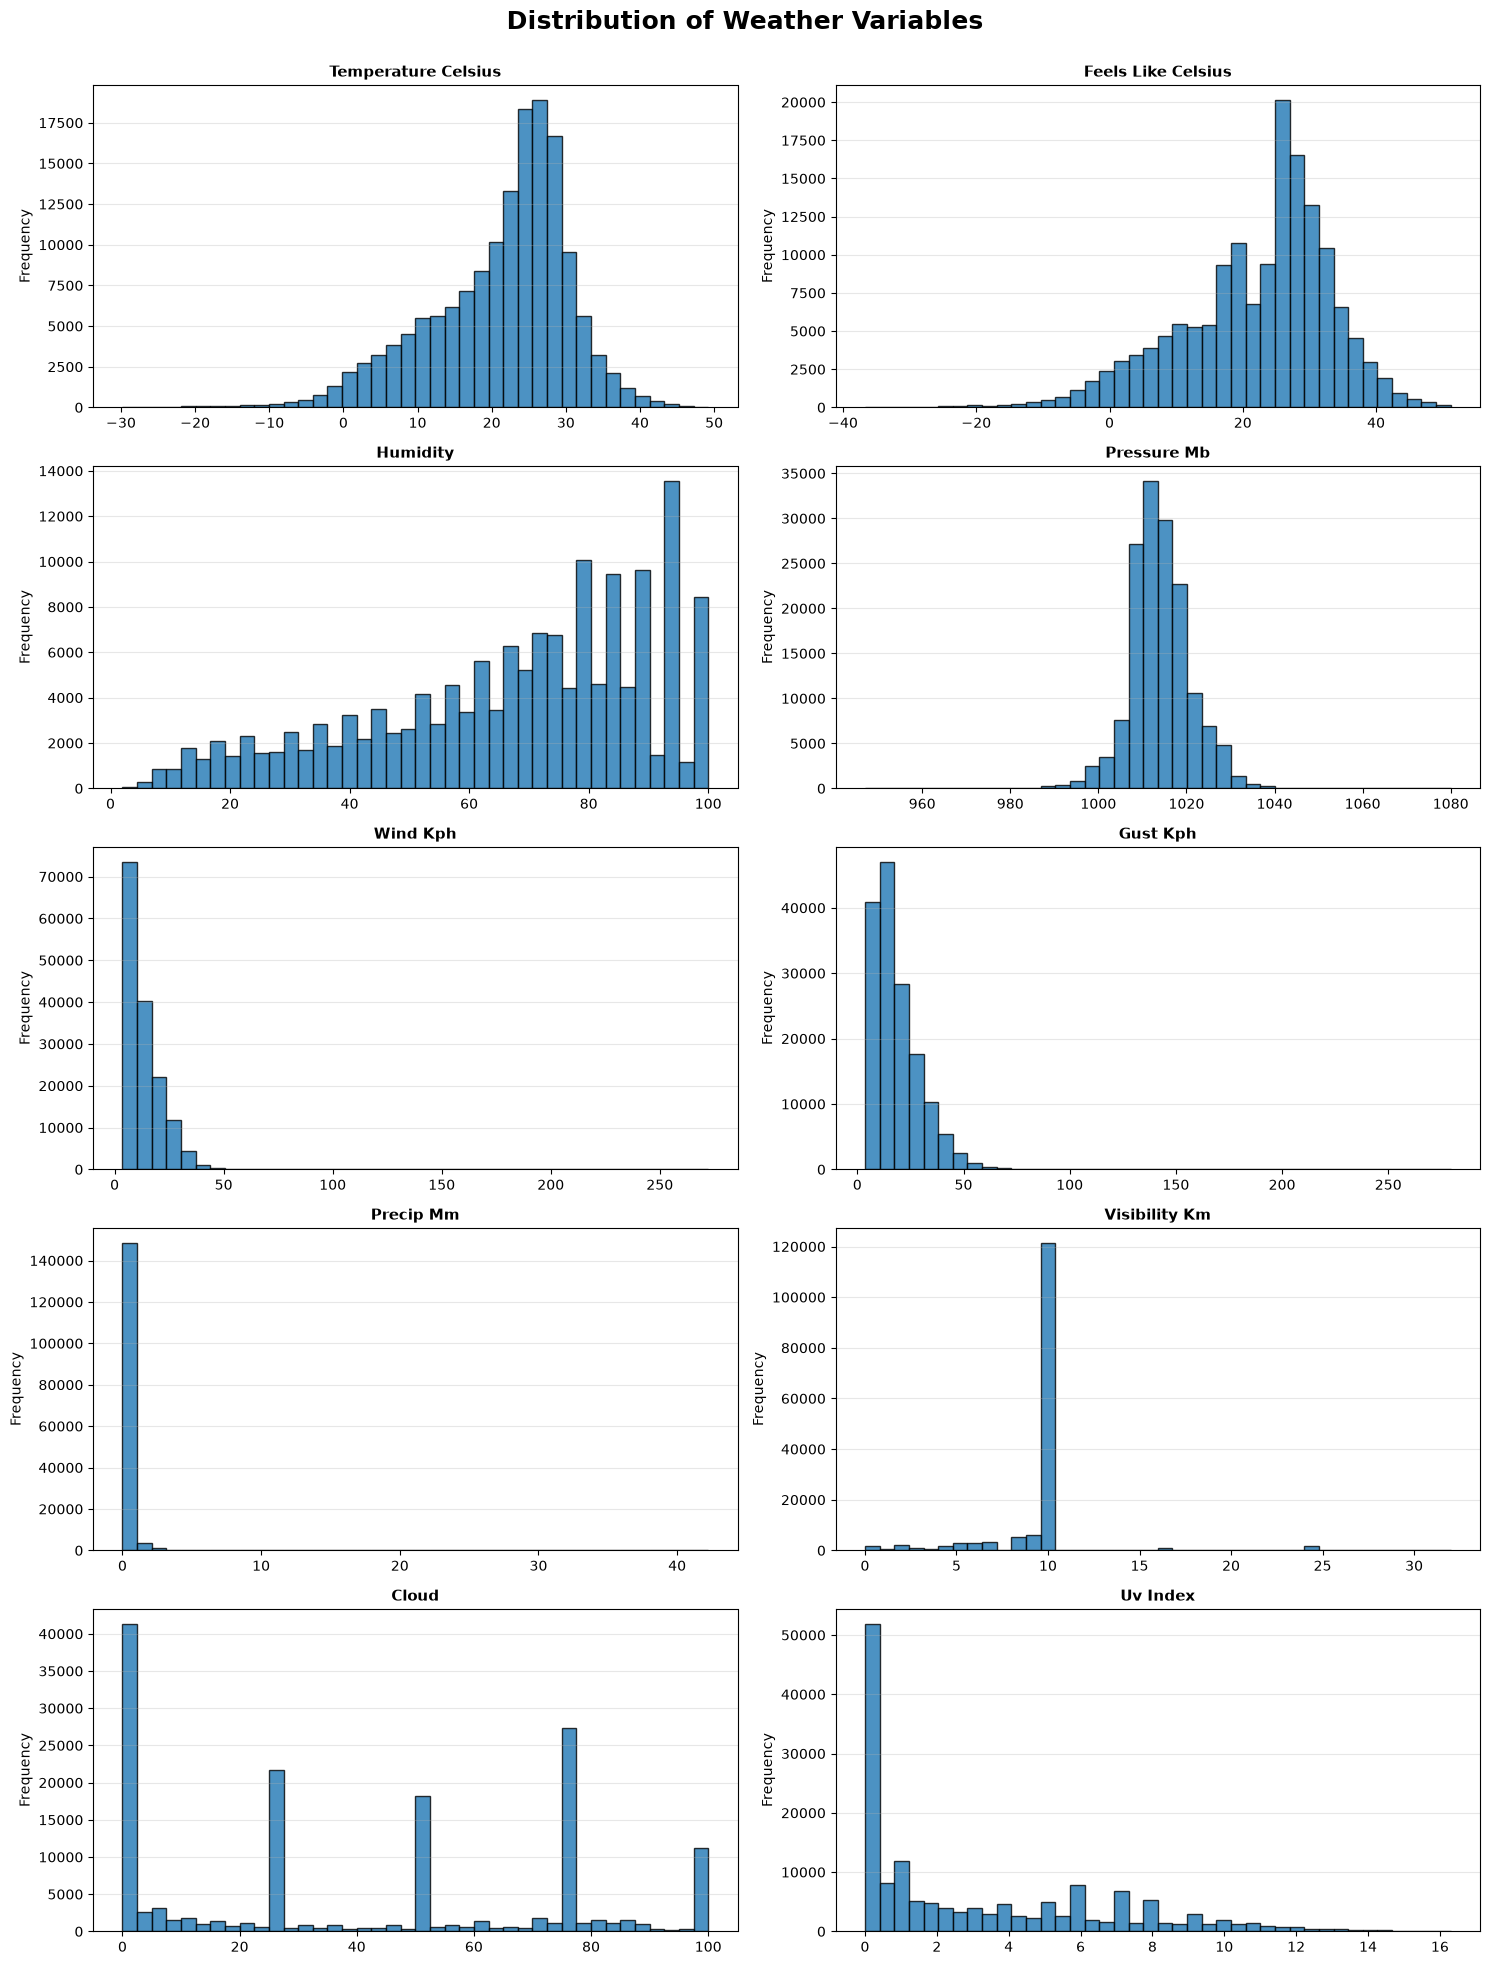

In [37]:
fig, axes = plt.subplots(5, 2, figsize=(15, 20))

for ax, column in zip(axes.flat, weather_columns):
    ax.hist(df[column], bins=40, edgecolor="black", alpha=0.8)
    ax.set_title(column.replace("_", " ").title(), fontsize=11, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Frequency")
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Distribution of Weather Variables", fontsize=18, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

The majority of weather variables do not follow a normal distribution. Variables such as wind speed, gust speed, precipitation and UV index exhibit positive skewness, while temperature and humidity show moderate negative skewness. These distributional characteristics are typical of meteorological datasets and indicate that extreme weather events occur much less frequently than normal weather conditions.
## Key Findings
- Temperature and Feels-like Temperature: Both variables exhibit a moderately left-skewed distribution, with most observations concentrated between 20°C and 30°C. The longer left tail reflects colder observations from cooler climatic regions.
- Humidity: Humidity is concentrated at relatively high values, with most observations between 60% and 90%. The distribution is moderately left-skewed, indicating that humid conditions are more common than very dry conditions.
- Atmospheric Pressure: Pressure follows an approximately normal (bell-shaped) distribution, centred around 1014 mb, suggesting relatively stable atmospheric conditions across the dataset.
- Wind Speed and Gust Speed: Both variables display strong positive skewness, with the majority of observations representing relatively low wind speeds and only a small number corresponding to severe wind events. Gust speeds are generally higher than sustained wind speeds, which is expected.
- Precipitation: The precipitation distribution is extremely right-skewed, with the vast majority of observations recording little or no rainfall. Only a small proportion of observations correspond to moderate or heavy precipitation events.
- Visibility: Most observations have visibility close to 10 km, indicating generally good visibility conditions. Lower visibility values occur relatively infrequently and are likely associated with fog, rain or other adverse weather conditions.
- Cloud Cover: Cloud cover is distributed across the full range from 0% to 100%, with noticeable peaks at common reporting levels such as 0%, 25%, 50%, 75% and 100%. This pattern likely reflects the way cloud cover is recorded by weather services rather than a continuous measurement.
- UV Index: The UV index is positively skewed, with most observations corresponding to low or moderate UV levels and comparatively fewer observations with very high UV values.


# Corelation Analysis

In [38]:
corr_matrix = df[weather_columns].corr()

display(corr_matrix.round(2))

,temperature_celsius,feels_like_celsius,humidity,pressure_mb,wind_kph,gust_kph,precip_mm,visibility_km,cloud,uv_index
temperature_celsius,1.00,0.98,-0.34,-0.43,0.13,0.10,0.03,0.10,-0.12,0.48
feels_like_celsius,0.98,1.00,-0.24,-0.42,0.10,0.09,0.06,0.12,-0.07,0.44
humidity,-0.34,-0.24,1.00,0.01,-0.10,-0.01,0.17,-0.11,0.50,-0.55
pressure_mb,-0.43,-0.42,0.01,1.00,-0.18,-0.21,-0.12,-0.02,-0.11,-0.10
wind_kph,0.13,0.10,-0.10,-0.18,1.00,0.93,0.01,0.13,0.04,0.07
gust_kph,0.10,0.09,-0.01,-0.21,0.93,1.00,0.06,0.13,0.06,-0.03
precip_mm,0.03,0.06,0.17,-0.12,0.01,0.06,1.00,-0.03,0.22,-0.05
visibility_km,0.10,0.12,-0.11,-0.02,0.13,0.13,-0.03,1.00,-0.05,0.03
cloud,-0.12,-0.07,0.50,-0.11,0.04,0.06,0.22,-0.05,1.00,-0.19
uv_index,0.48,0.44,-0.55,-0.10,0.07,-0.03,-0.05,0.03,-0.19,1.00


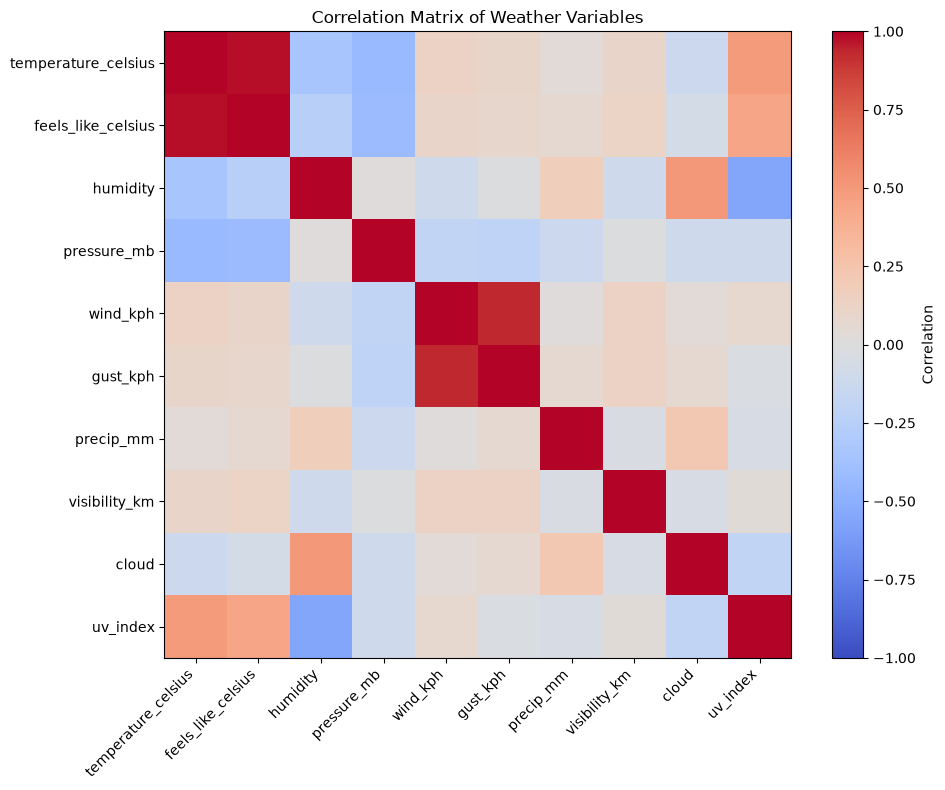

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

plt.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns
)

plt.title("Correlation Matrix of Weather Variables")

plt.tight_layout()

plt.show()

In [40]:
corr_pairs = (
    corr_matrix.where(~np.eye(corr_matrix.shape[0], dtype=bool))
    .stack()
    .reset_index()
)

corr_pairs.columns = [
    "Variable 1",
    "Variable 2",
    "Correlation"
]

corr_pairs["Absolute"] = corr_pairs["Correlation"].abs()

corr_pairs = (
    corr_pairs
    .sort_values("Absolute", ascending=False)
    .drop_duplicates(subset="Absolute")
)

display(corr_pairs.head(15))

,Variable 1,Variable 2,Correlation,Absolute
1,temperature_celsius,feels_like_celsius,0.980275,0.980275
54,gust_kph,wind_kph,0.932244,0.932244
92,uv_index,humidity,-0.549063,0.549063
28,humidity,cloud,0.503171,0.503171
90,uv_index,temperature_celsius,0.484935,0.484935
19,feels_like_celsius,uv_index,0.435014,0.435014
30,pressure_mb,temperature_celsius,-0.425128,0.425128
13,feels_like_celsius,pressure_mb,-0.421862,0.421862
2,temperature_celsius,humidity,-0.340488,0.340488
21,humidity,feels_like_celsius,-0.243558,0.243558


Pearson correlation analysis was performed to examine the linear relationships between the numerical weather variables. The strongest correlations are consistent with expected meteorological behaviour.

Key Findings
- Temperature and feels-like temperature exhibit an extremely strong positive correlation (r = 0.98). This is expected because the feels-like temperature is largely derived from the measured air temperature while also accounting for factors such as humidity and wind.
- Wind speed and gust speed show a very strong positive correlation (r = 0.93), indicating that locations experiencing stronger sustained winds also tend to experience stronger wind gusts.
- UV index and humidity have a moderate negative correlation (r = -0.55), suggesting that higher humidity is generally associated with lower UV levels, likely due to increased cloud cover and atmospheric moisture reducing solar radiation.
- Humidity and cloud cover demonstrate a moderate positive correlation (r = 0.50), reflecting the tendency for more humid conditions to coincide with increased cloud formation.
- Temperature and UV index are moderately positively correlated (r = 0.48), indicating that warmer conditions are often associated with higher levels of solar radiation.
- Atmospheric pressure has a moderate negative correlation with temperature (r = -0.43) and feels-like temperature (r = -0.42). This suggests that warmer conditions are often associated with relatively lower pressure systems.
- Temperature and humidity exhibit a moderate negative correlation (r = -0.34), indicating that higher temperatures in the dataset generally coincide with lower relative humidity.
- Precipitation and cloud cover show a weak positive relationship (r = 0.22), which is expected since rainfall is more likely under cloudy conditions, although cloud cover alone does not fully explain precipitation.

Overall, the analysis indicates that while several weather variables exhibit strong linear relationships, many correlations are only moderate or weak. This reflects the complexity of atmospheric processes, where weather conditions are influenced by multiple interacting factors rather than a single variable.

# Temporal Analysis

## Monthly Observation Count

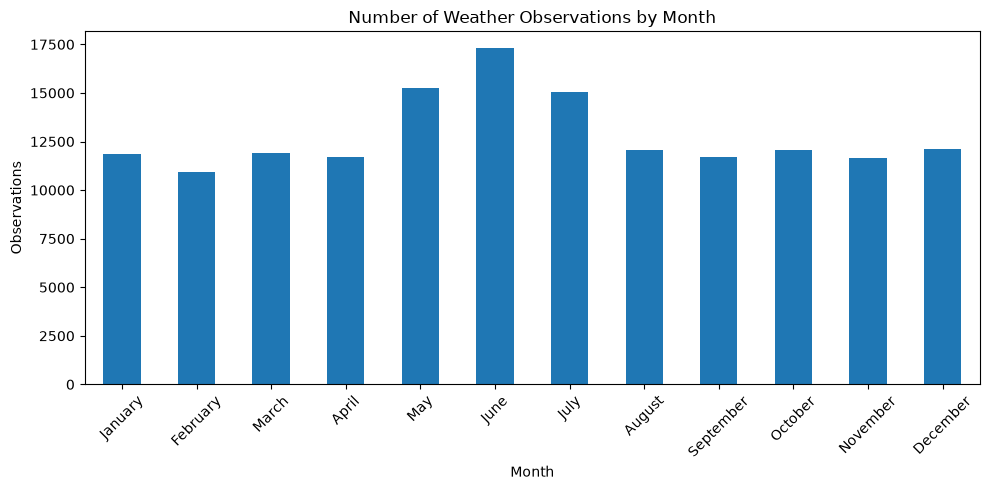

In [43]:
monthly_counts = (
    df.groupby("month_name", observed=False)
      .size()
      .reindex([
          "January", "February", "March", "April",
          "May", "June", "July", "August",
          "September", "October", "November", "December"
      ])
)

plt.figure(figsize=(10,5))
monthly_counts.plot(kind="bar")

plt.title("Number of Weather Observations by Month")
plt.xlabel("Month")
plt.ylabel("Observations")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

The number of weather observations is relatively consistent throughout the year, indicating good temporal coverage across all months. Observation counts range from approximately 11,000 to 17,500 records per month. A noticeable increase is observed during May, June, and July, with June containing the highest number of observations, while February has the fewest. Although there is some variation in monthly sample sizes, no month is severely underrepresented. This suggests that the dataset is suitable for analysing seasonal weather patterns without substantial temporal sampling bias.
The peak around May–July is likely due to the period covered by this dataset (roughly May 2024 to July 2026), rather than because weather stations collect more observations in summer.



## Average temperature by month

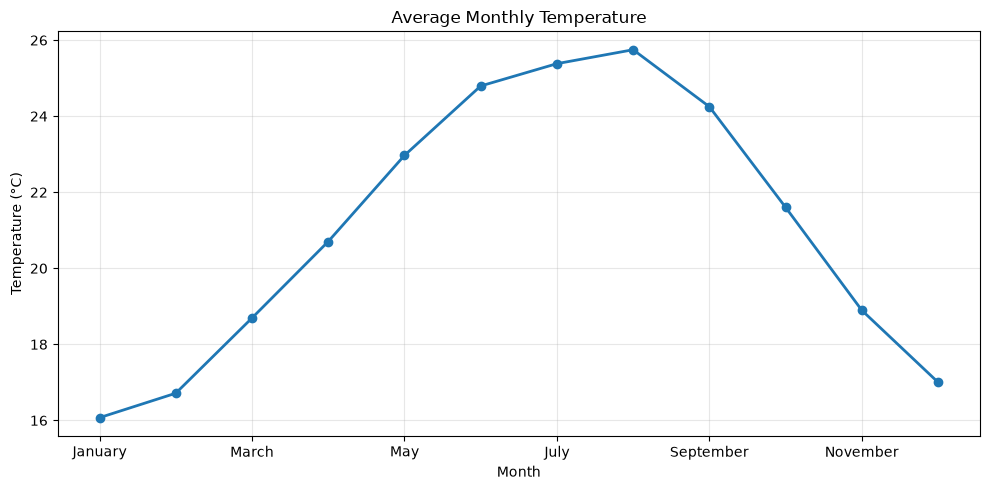

In [44]:
monthly_temperature = (
    df.groupby("month_name", observed=False)["temperature_celsius"]
      .mean()
      .reindex([
          "January", "February", "March", "April",
          "May", "June", "July", "August",
          "September", "October", "November", "December"
      ])
)

plt.figure(figsize=(10,5))

monthly_temperature.plot(
    marker="o",
    linewidth=2
)

plt.title("Average Monthly Temperature")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Average Humidty by Month 

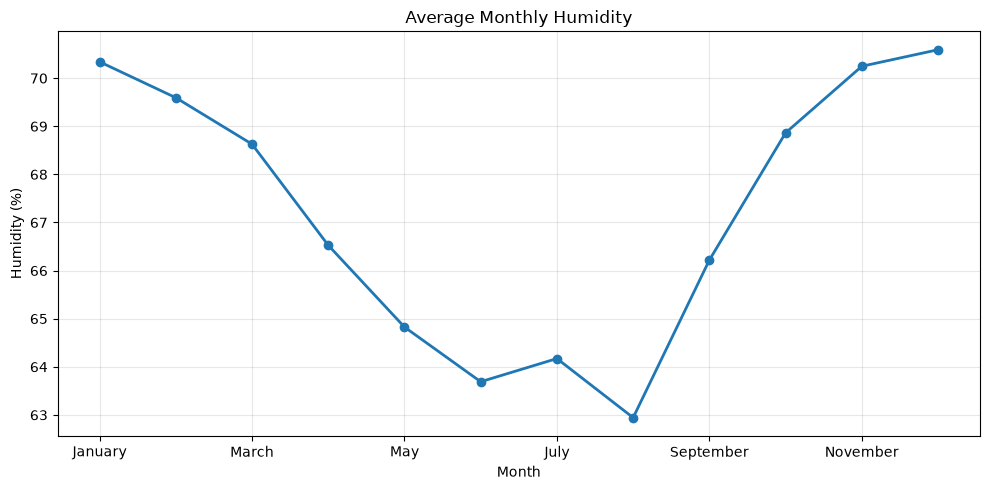

In [45]:
monthly_humidity = (
    df.groupby("month_name", observed=False)["humidity"]
      .mean()
      .reindex(monthly_temperature.index)
)

plt.figure(figsize=(10,5))

monthly_humidity.plot(
    marker="o",
    linewidth=2
)

plt.title("Average Monthly Humidity")
plt.xlabel("Month")
plt.ylabel("Humidity (%)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Average Precipitation by Month

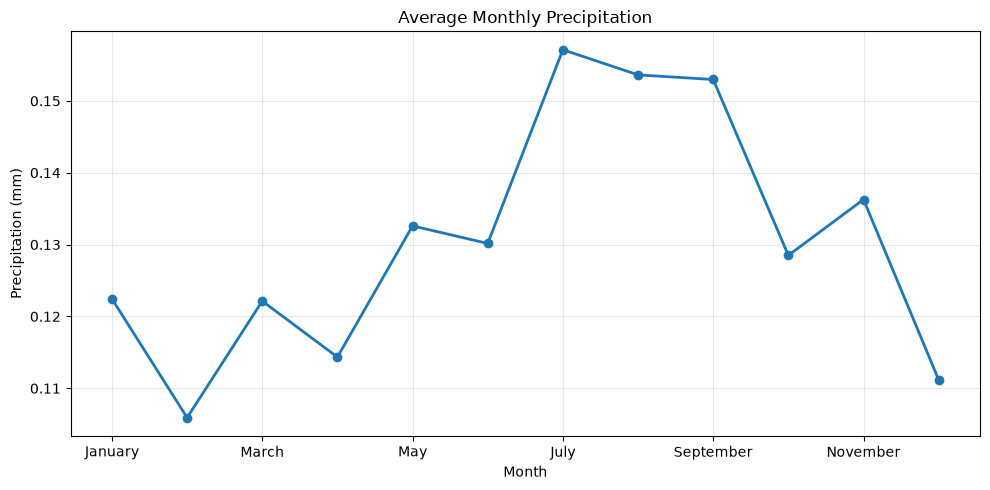

In [46]:
monthly_precip = (
    df.groupby("month_name", observed=False)["precip_mm"]
      .mean()
      .reindex(monthly_temperature.index)
)

plt.figure(figsize=(10,5))

monthly_precip.plot(
    marker="o",
    linewidth=2
)

plt.title("Average Monthly Precipitation")
plt.xlabel("Month")
plt.ylabel("Precipitation (mm)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Average Wind Speed by Month

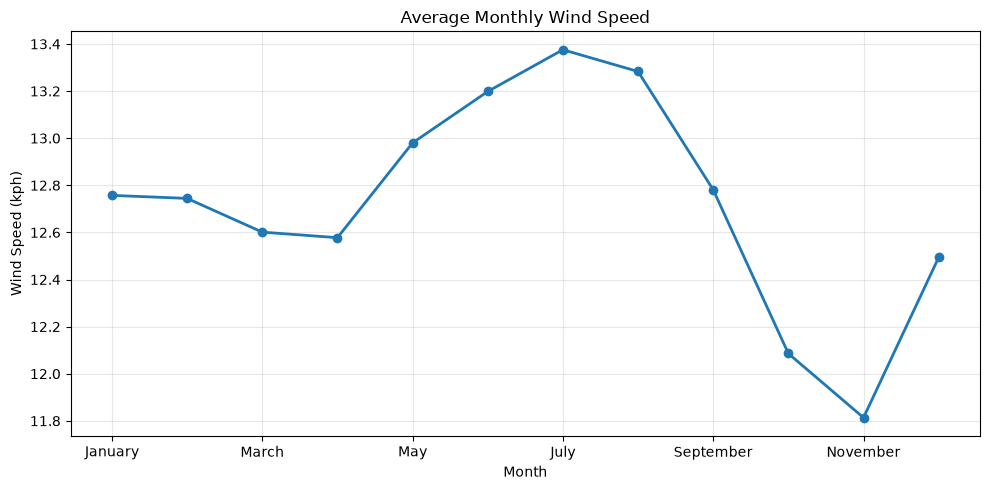

In [47]:
monthly_wind = (
    df.groupby("month_name", observed=False)["wind_kph"]
      .mean()
      .reindex(monthly_temperature.index)
)

plt.figure(figsize=(10,5))

monthly_wind.plot(
    marker="o",
    linewidth=2
)

plt.title("Average Monthly Wind Speed")
plt.xlabel("Month")
plt.ylabel("Wind Speed (kph)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Key Findings
- Temperature exhibits a clear seasonal pattern, increasing steadily from approximately 16°C in January to a peak of 26°C in August, before declining towards the end of the year. This indicates strong annual seasonality within the dataset.
- Humidity follows an inverse pattern to temperature. Average humidity is highest during the winter months (approximately 70%) and decreases to around 63% during August, suggesting that warmer periods are generally associated with drier atmospheric conditions.
- Precipitation remains relatively low throughout the year but increases slightly during July to September, indicating a modest seasonal increase in rainfall during mid-year.
- Wind speed varies only slightly across the year, ranging between approximately 11.8 and 13.4 kph. Wind speeds are marginally higher during the summer months and lower during late autumn, although seasonal variation is considerably smaller than that observed for temperature.


The temporal analysis demonstrates that several weather variables exhibit clear seasonal behaviour. Temperature shows the strongest annual cycle, while humidity displays an opposite seasonal trend. Precipitation and wind speed exhibit comparatively smaller seasonal fluctuations.

These recurring monthly patterns suggest that time-related features such as month and day of year are likely to be valuable predictors for weather forecasting models, as they capture systematic seasonal variation in the data.

## Temperature by Hour

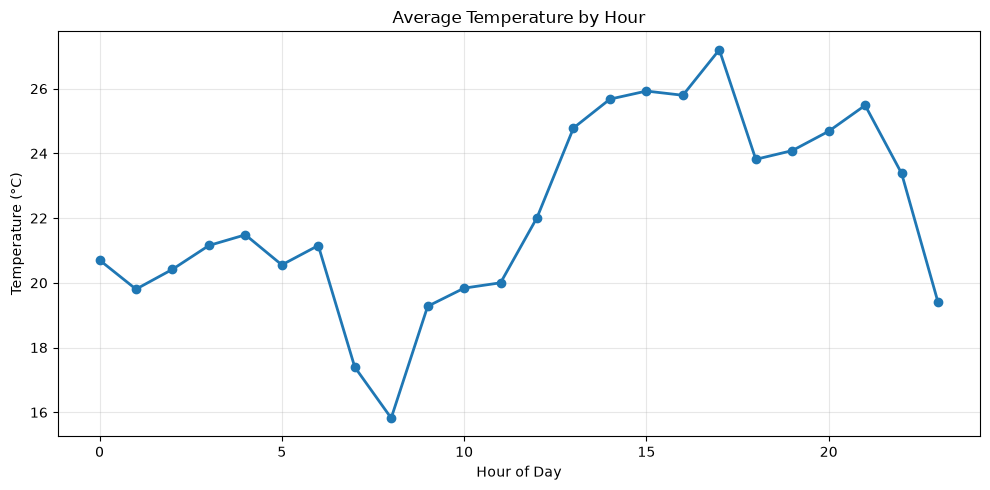

In [48]:
hourly_temperature = (
    df.groupby("hour")["temperature_celsius"]
      .mean()
)

plt.figure(figsize=(10,5))

hourly_temperature.plot(
    marker="o",
    linewidth=2
)

plt.title("Average Temperature by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Temperature (°C)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

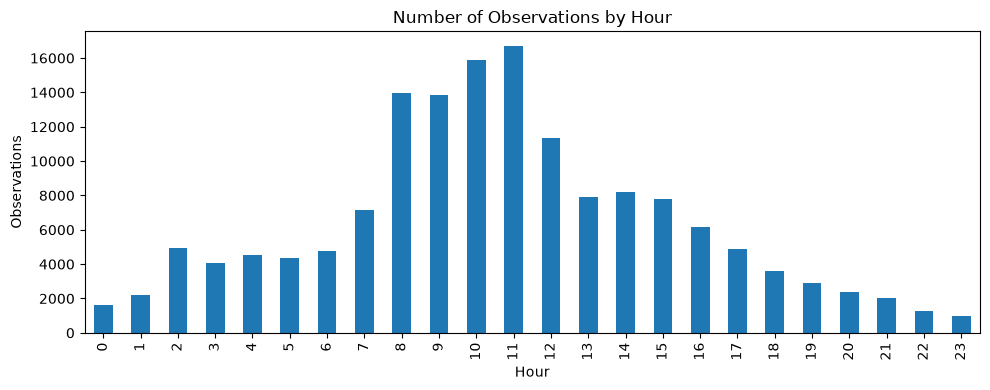

hour
0      1607
1      2194
2      4950
3      4095
4      4559
5      4366
6      4784
7      7130
8     13970
9     13854
10    15859
11    16720
12    11316
13     7914
14     8221
15     7809
16     6146
17     4898
18     3609
19     2914
20     2398
21     2025
22     1265
23      974
dtype: int64

In [50]:
hourly_counts = df.groupby("hour").size()

plt.figure(figsize=(10,4))
hourly_counts.plot(kind="bar")
plt.title("Number of Observations by Hour")
plt.xlabel("Hour")
plt.ylabel("Observations")
plt.tight_layout()
plt.show()

display(hourly_counts)

number of observations is not evenly distributed throughout the day. Midday hours contain substantially more observations than late evening and overnight hours, which may influence the calculated averages.

## Humidity by Hour

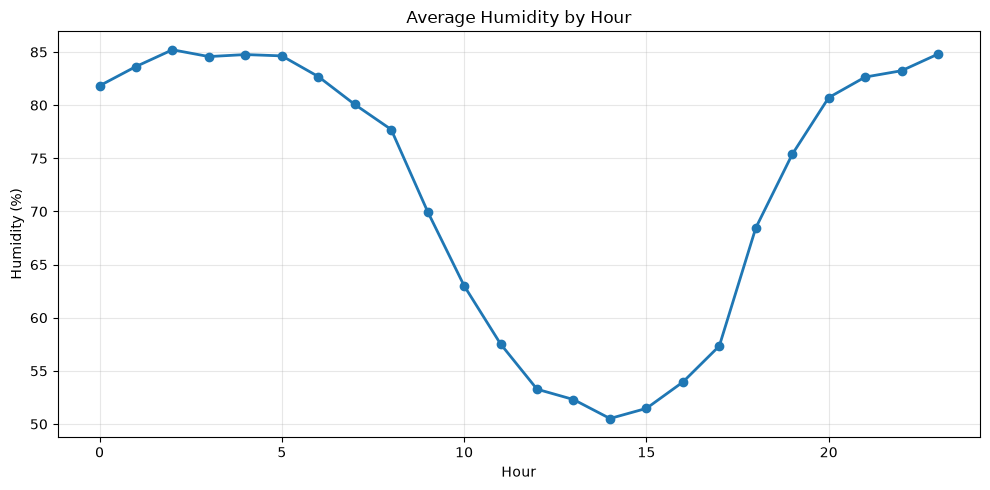

In [49]:
hourly_humidity = (
    df.groupby("hour")["humidity"]
      .mean()
)

plt.figure(figsize=(10,5))

hourly_humidity.plot(
    marker="o",
    linewidth=2
)

plt.title("Average Humidity by Hour")
plt.xlabel("Hour")
plt.ylabel("Humidity (%)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

<Axes: xlabel='hour'>

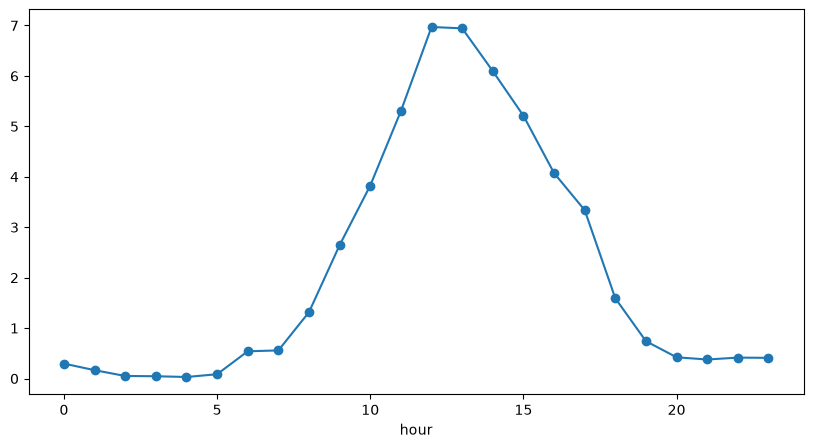

In [69]:
hourly_uv = (
    df.groupby("hour")["uv_index"]
      .mean()
)

hourly_uv.plot(
    marker="o",
    figsize=(10,5)
)

The average hourly temperature and humidity were analysed to investigate daily weather cycles across the dataset.

Key Findings
- Temperature generally increases throughout the day, reaching its highest values during the afternoon (approximately 15:00–17:00) before gradually decreasing during the evening and overnight. This pattern reflects the daily heating and cooling cycle driven by solar radiation.
- Humidity exhibits the opposite behaviour. Relative humidity is highest during the late evening, overnight and early morning, exceeding 80%, before decreasing steadily to its lowest levels during the afternoon (approximately 50%). This inverse relationship occurs because warmer air can hold more moisture, reducing relative humidity as temperatures increase.
- The opposite trends observed in temperature and humidity are consistent with established atmospheric processes and further support the moderate negative correlation identified between these variables during the correlation analysis.
Overall Interpretation

The presence of clear daily cycles indicates that weather variables exhibit strong temporal dependence rather than random variation. Consequently, hour of day is likely to be an informative predictor for forecasting models, particularly when predicting temperature and humidity.

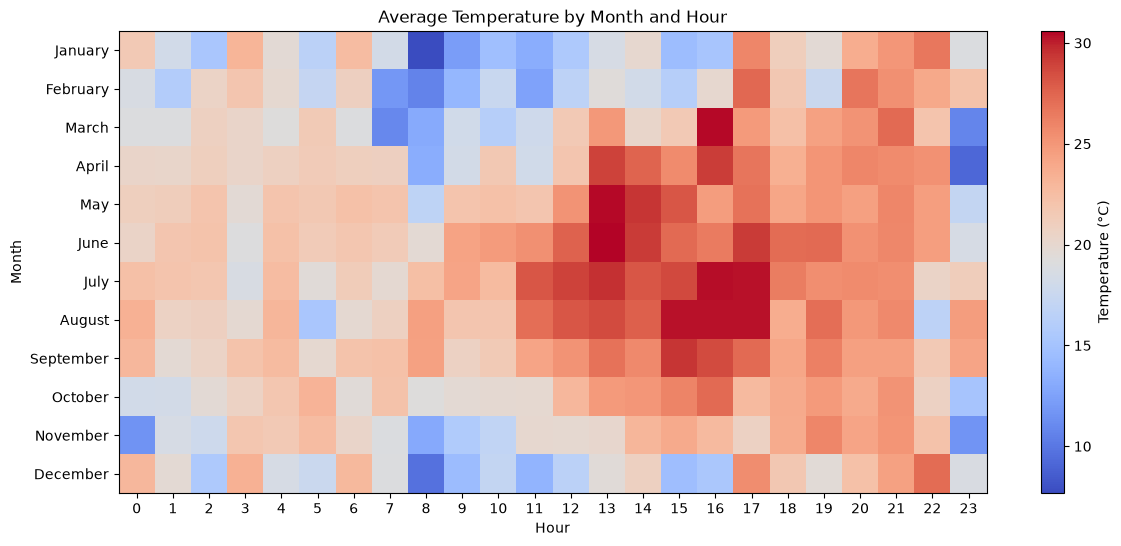

In [54]:
temp_heatmap = df.pivot_table(
    values="temperature_celsius",
    index="month_name",
    columns="hour",
    aggfunc="mean",
    observed=False
)

month_order = [
    "January","February","March","April",
    "May","June","July","August",
    "September","October","November","December"
]

temp_heatmap = temp_heatmap.reindex(month_order)

plt.figure(figsize=(14,6))

plt.imshow(
    temp_heatmap,
    aspect="auto",
    cmap="coolwarm"
)

plt.colorbar(label="Temperature (°C)")

plt.xticks(range(24), range(24))
plt.yticks(range(12), month_order)

plt.xlabel("Hour")
plt.ylabel("Month")
plt.title("Average Temperature by Month and Hour")

plt.show()

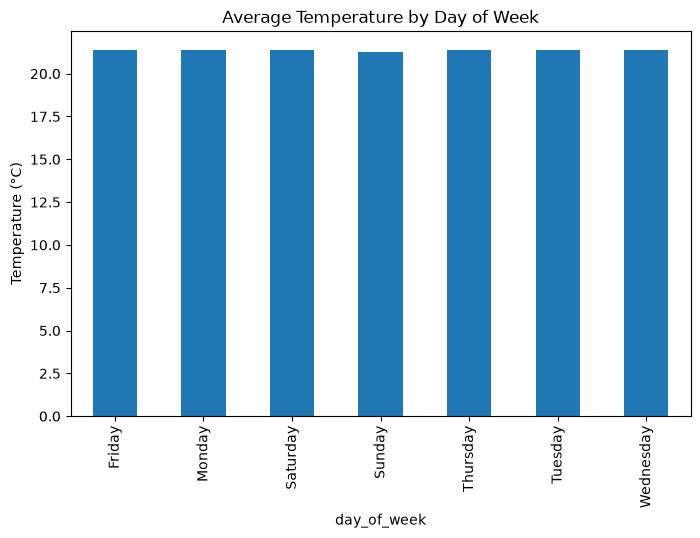

In [53]:
weekday_temperature = (
    df.groupby("day_of_week", observed=False)["temperature_celsius"]
      .mean()
)

weekday_temperature.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Temperature by Day of Week")
plt.ylabel("Temperature (°C)")
plt.show()

Although weather doesn't "know" weekdays, plotting this verifies there is no systematic weekly bias, which is a good data quality check.

## Sunrise Sunset Analysis

In [58]:
date = pd.to_datetime(df["last_updated"]).dt.date.astype(str)

df["sunrise_dt"] = pd.to_datetime(
    date + " " + df["sunrise"]
)

df["sunset_dt"] = pd.to_datetime(
    date + " " + df["sunset"]
)

df["daylight_hours"] = (
    df["sunset_dt"] - df["sunrise_dt"]
).dt.total_seconds() / 3600

C:\Users\Aeiman Imtiaz\AppData\Local\Temp\ipykernel_6556\4158681567.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["sunset_dt"] = pd.to_datetime(


In [59]:
df["daylight_hours"].describe()

count    153577.000000
mean         12.272095
std           1.759304
min          -2.916667
25%          11.466667
50%          12.166667
75%          12.983333
max          21.483333
Name: daylight_hours, dtype: float64

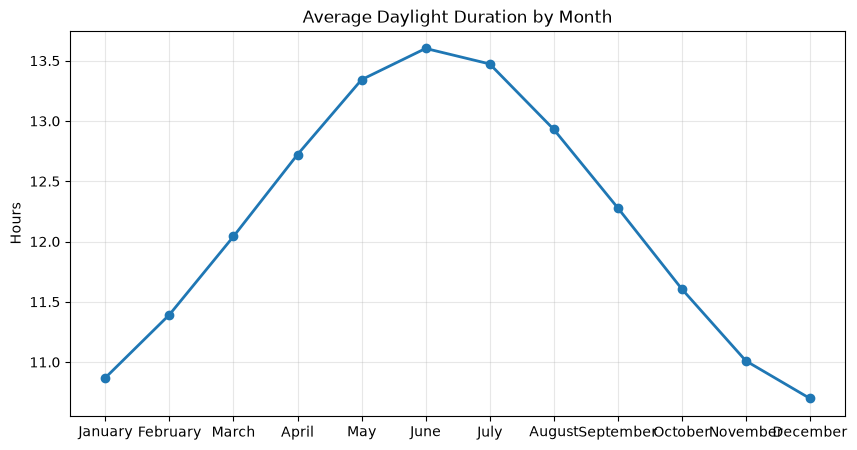

In [60]:
month_order = [
    "January","February","March","April",
    "May","June","July","August",
    "September","October","November","December"
]

monthly_daylight = (
    df.groupby("month_name", observed=False)["daylight_hours"]
      .mean()
      .reindex(month_order)
)

plt.figure(figsize=(10,5))

plt.plot(
    monthly_daylight,
    marker="o",
    linewidth=2
)

plt.title("Average Daylight Duration by Month")
plt.ylabel("Hours")

plt.grid(alpha=0.3)

plt.show()

### Top 20 weather Conditions

In [79]:
unique_conditions = (
    df["condition_text"]
    .dropna()
    .sort_values()
    .unique()
)

for condition in unique_conditions:
    print(condition)

Blizzard
Blowing dust
Blowing snow
Clear
Cloudy
Dust haze
Dust storm
Fog
Freezing drizzle
Freezing fog
Haze
Heavy freezing drizzle
Heavy rain
Heavy rain at times
Heavy snow
Light drizzle
Light freezing rain
Light rain
Light rain shower
Light sleet
Light sleet showers
Light snow
Light snow showers
Mist
Moderate or heavy freezing rain
Moderate or heavy rain in area with thunder
Moderate or heavy rain shower
Moderate or heavy rain with thunder
Moderate or heavy sleet
Moderate or heavy snow in area with thunder
Moderate or heavy snow showers
Moderate rain
Moderate rain at times
Moderate snow
Overcast
Partly Cloudy
Partly cloudy
Patchy heavy snow
Patchy light drizzle
Patchy light rain
Patchy light rain in area with thunder
Patchy light rain with thunder
Patchy light snow
Patchy light snow in area with thunder
Patchy moderate snow
Patchy rain nearby
Patchy rain possible
Patchy snow nearby
Patchy snow possible
Sandstorm
Severe sandstorm
Smog
Smoky haze
Sunny
Thundery outbreaks in nearby
Thund

In [80]:
condition_counts = (
    df["condition_text"]
    .value_counts()
    .reset_index()
)

condition_counts.columns = ["Weather Condition", "Observations"]

display(condition_counts)

,Weather Condition,Observations
0,Sunny,44952
1,Partly cloudy,42380
2,Patchy rain nearby,13209
3,Partly Cloudy,10342
4,Clear,8307
5,Overcast,8184
6,Mist,6302
7,Light rain,4698
8,Light rain shower,3519
9,Fog,1922


In [81]:
condition = df["condition_text"].str.lower()

conditions = [

    # Thunderstorms
    condition.str.contains(
        "thunder|thundery",
        regex=True
    ),

    # Snow / Ice
    condition.str.contains(
        "snow|sleet|freezing|blizzard",
        regex=True
    ),

    # Rain / Drizzle
    condition.str.contains(
        "rain|drizzle|shower",
        regex=True
    ),

    # Clouds
    condition.str.contains(
        "cloud|overcast",
        regex=True
    ),

    # Clear
    condition.str.contains(
        "sunny|clear",
        regex=True
    ),

    # Fog / Haze
    condition.str.contains(
        "fog|mist|haze|smog",
        regex=True
    ),

    # Dust / Sand
    condition.str.contains(
        "dust|sand",
        regex=True
    )

]

categories = [

    "Thunderstorm",
    "Snow / Ice",
    "Rain / Drizzle",
    "Cloudy / Overcast",
    "Clear / Sunny",
    "Fog / Haze",
    "Dust / Sand"

]

df["weather_category"] = np.select(
    conditions,
    categories,
    default="Other"
)

In [82]:
pd.crosstab(
    df["weather_category"],
    df["condition_text"]
)

condition_text,Blizzard,Blowing dust,Blowing snow,Clear,Cloudy,Dust haze,Dust storm,Fog,Freezing drizzle,Freezing fog,...,Patchy snow nearby,Patchy snow possible,Sandstorm,Severe sandstorm,Smog,Smoky haze,Sunny,Thundery outbreaks in nearby,Thundery outbreaks possible,Torrential rain shower
weather_category,,,,,,,,,,,,,,,,,,,,,
Clear / Sunny,0,0,0,8307,0,0,0,0,0,0,...,0,0,0,0,0,0,44952,0,0,0
Cloudy / Overcast,0,0,0,0,1899,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Dust / Sand,0,10,0,0,0,0,46,0,0,0,...,0,0,16,42,0,0,0,0,0,0
Fog / Haze,0,0,0,0,0,4,0,1922,0,0,...,0,0,0,0,20,175,0,0,0,0
Rain / Drizzle,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,19
Snow / Ice,10,0,41,0,0,0,0,0,5,248,...,3,5,0,0,0,0,0,0,0,0
Thunderstorm,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,331,30,0


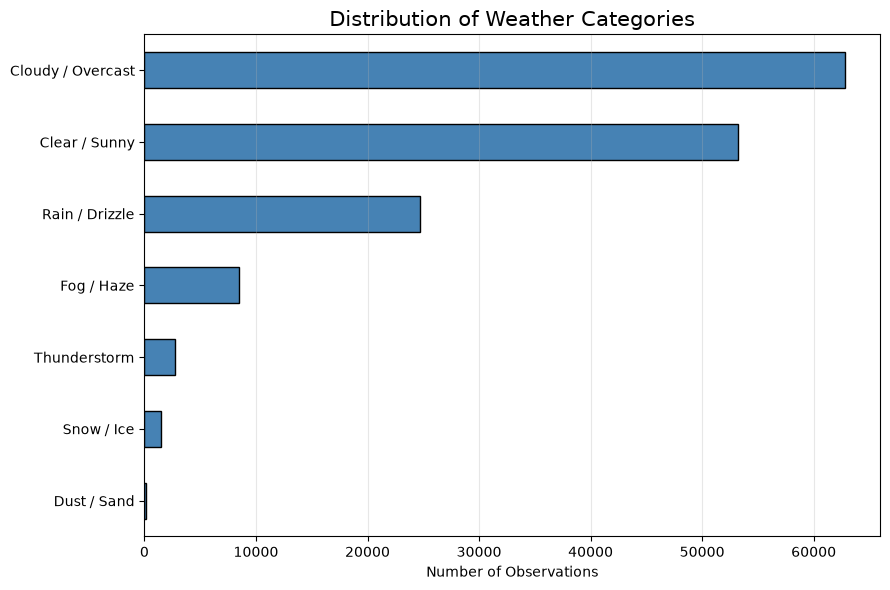

In [83]:
weather_counts = (
    df["weather_category"]
    .value_counts()
    .sort_values()
)

plt.figure(figsize=(9,6))

weather_counts.plot(
    kind="barh",
    color="steelblue",
    edgecolor="black"
)

plt.title("Distribution of Weather Categories", fontsize=15)
plt.xlabel("Number of Observations")
plt.ylabel("")
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

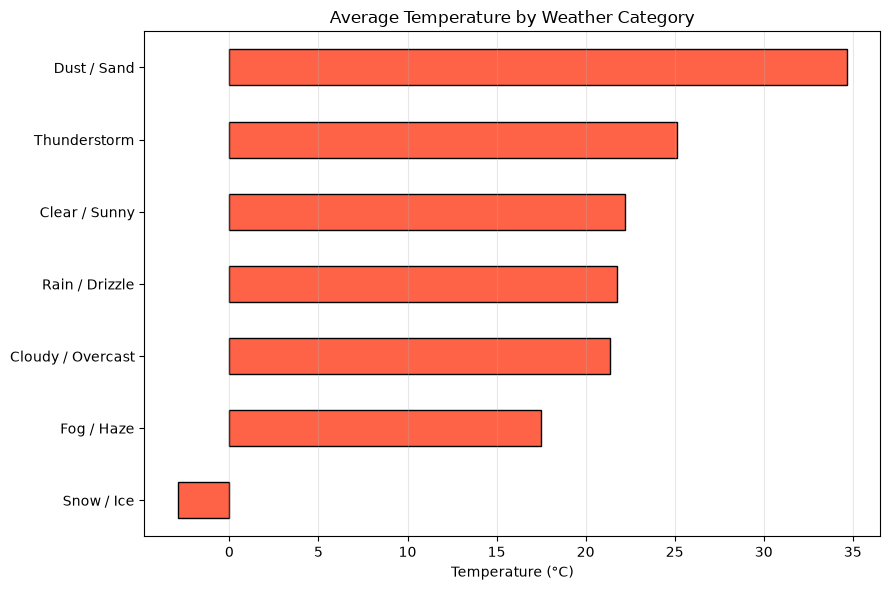

In [84]:
temperature = (
    df.groupby("weather_category")["temperature_celsius"]
      .mean()
      .sort_values()
)

plt.figure(figsize=(9,6))

temperature.plot(
    kind="barh",
    color="tomato",
    edgecolor="black"
)

plt.title("Average Temperature by Weather Category")
plt.xlabel("Temperature (°C)")
plt.ylabel("")
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

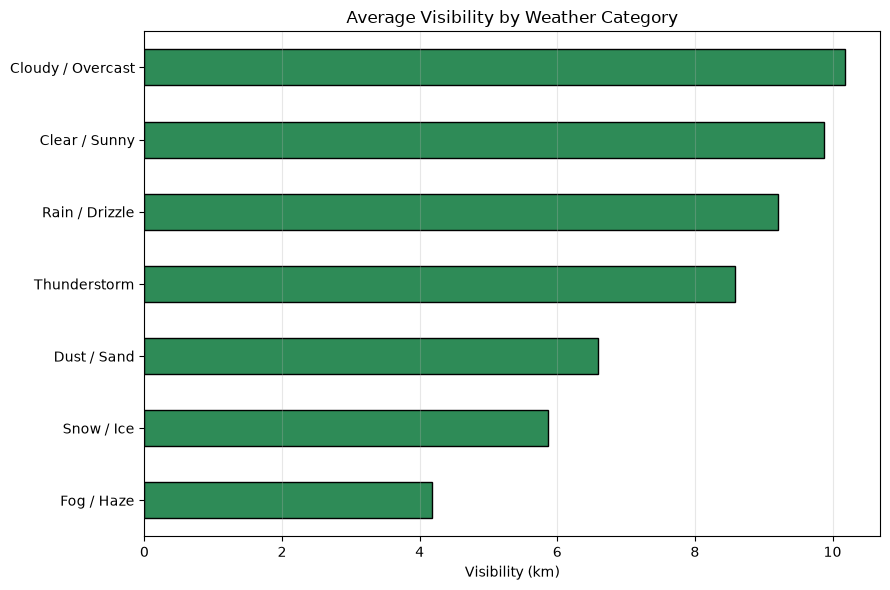

In [85]:
visibility = (
    df.groupby("weather_category")["visibility_km"]
      .mean()
      .sort_values()
)

plt.figure(figsize=(9,6))

visibility.plot(
    kind="barh",
    color="seagreen",
    edgecolor="black"
)

plt.title("Average Visibility by Weather Category")
plt.xlabel("Visibility (km)")
plt.ylabel("")
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

In [70]:
air_quality_columns = [
    "air_quality_Carbon_Monoxide",
    "air_quality_Ozone",
    "air_quality_Nitrogen_dioxide",
    "air_quality_Sulphur_dioxide",
    "air_quality_PM2.5",
    "air_quality_PM10"
]

air_summary = df[air_quality_columns].describe().T

display(air_summary)

,count,mean,std,min,25%,50%,75%,max
air_quality_Carbon_Monoxide,153577.0,433.902529,722.490537,53.850,185.30,277.500,436.850,38879.398
air_quality_Ozone,153577.0,57.779001,30.739353,0.000,38.00,55.000,73.000,480.700
air_quality_Nitrogen_dioxide,153577.0,14.405542,22.816234,0.000,1.75,5.550,16.465,427.700
air_quality_Sulphur_dioxide,153577.0,9.937963,22.126706,0.000,1.11,2.405,7.770,521.330
air_quality_PM2.5,153577.0,23.328627,35.400514,0.168,6.90,13.550,26.640,1614.100
air_quality_PM10,153577.0,46.879727,144.047677,0.168,9.70,19.240,40.100,6037.290


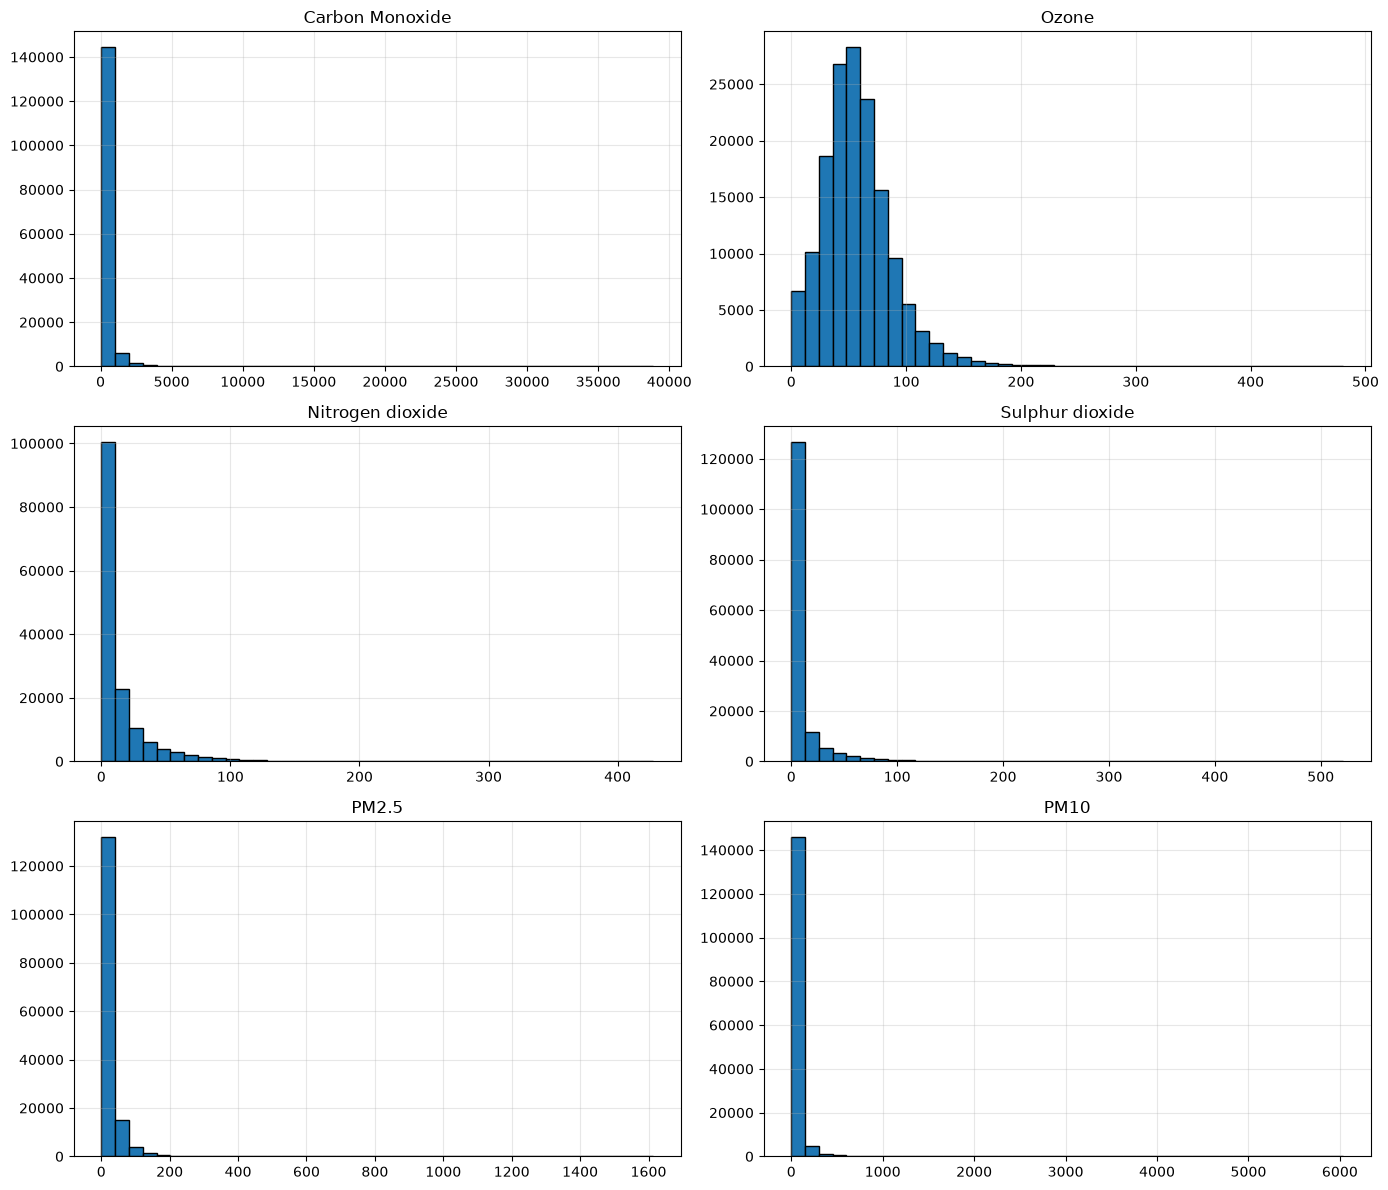

In [71]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, column in zip(axes, air_quality_columns):
    ax.hist(df[column], bins=40, edgecolor="black")
    ax.set_title(column.replace("air_quality_", "").replace("_", " "))
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Air Quality Correlation Heatmap

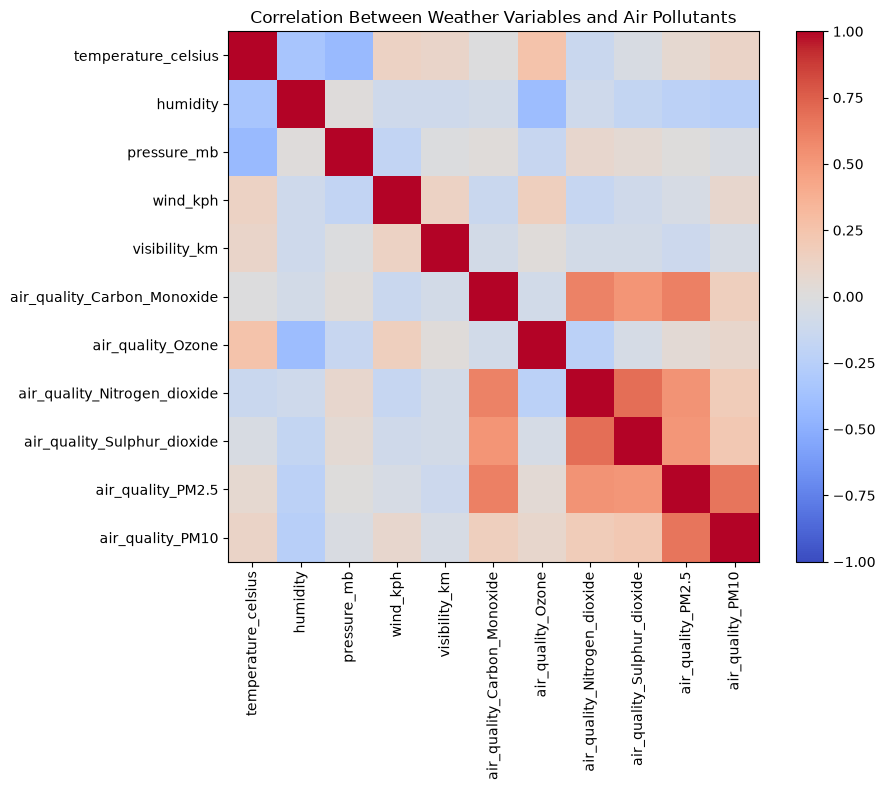

In [72]:
weather_air_columns = [
    "temperature_celsius",
    "humidity",
    "pressure_mb",
    "wind_kph",
    "visibility_km",
    "air_quality_Carbon_Monoxide",
    "air_quality_Ozone",
    "air_quality_Nitrogen_dioxide",
    "air_quality_Sulphur_dioxide",
    "air_quality_PM2.5",
    "air_quality_PM10"
]

corr = df[weather_air_columns].corr()

plt.figure(figsize=(10,8))

plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("Correlation Between Weather Variables and Air Pollutants")

plt.tight_layout()

plt.show()

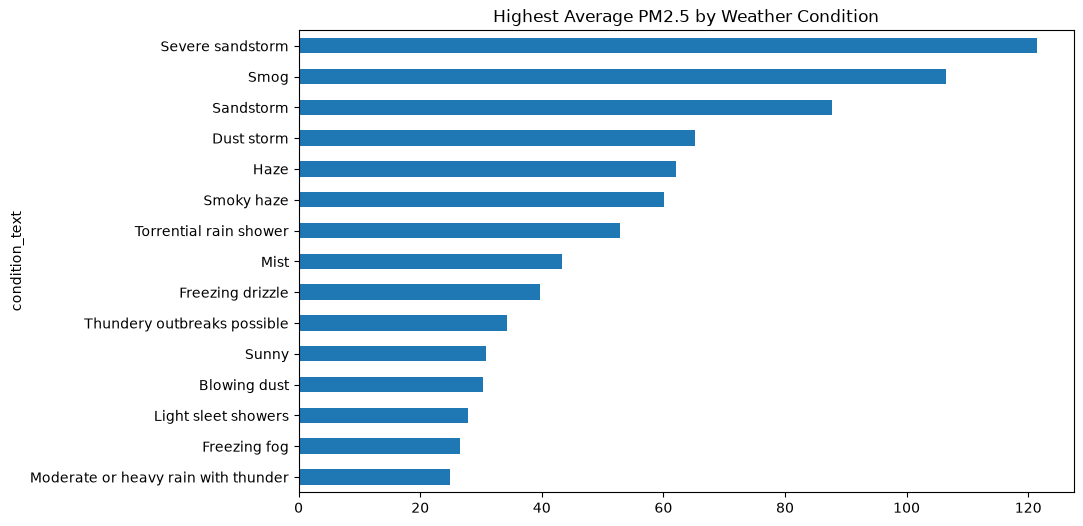

In [73]:
pm_condition = (
    df.groupby("condition_text")["air_quality_PM2.5"]
      .mean()
      .sort_values()
)

pm_condition.tail(15).plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Highest Average PM2.5 by Weather Condition")
plt.show()

## Air Quality by Month

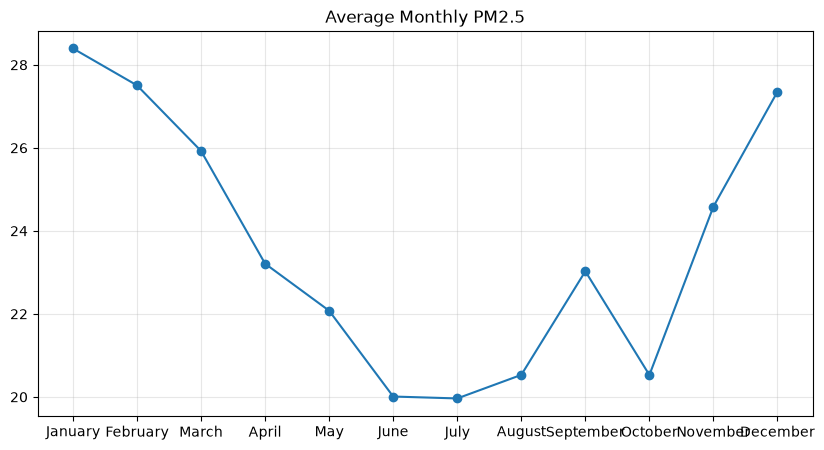

In [74]:
monthly_pm = (
    df.groupby("month_name", observed=False)["air_quality_PM2.5"]
      .mean()
      .reindex(month_order)
)

plt.figure(figsize=(10,5))

plt.plot(
    monthly_pm,
    marker="o"
)

plt.title("Average Monthly PM2.5")

plt.grid(alpha=0.3)

plt.show()

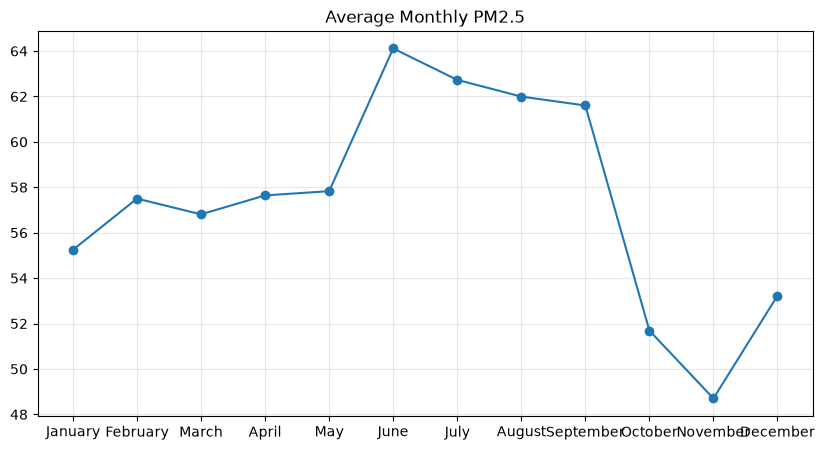

In [77]:
monthly_pm = (
    df.groupby("month_name", observed=False)["air_quality_Ozone"]
      .mean()
      .reindex(month_order)
)

plt.figure(figsize=(10,5))

plt.plot(
    monthly_pm,
    marker="o"
)

plt.title("Average Monthly PM2.5")

plt.grid(alpha=0.3)

plt.show()

## Relationship Between Visibility and PM2.5

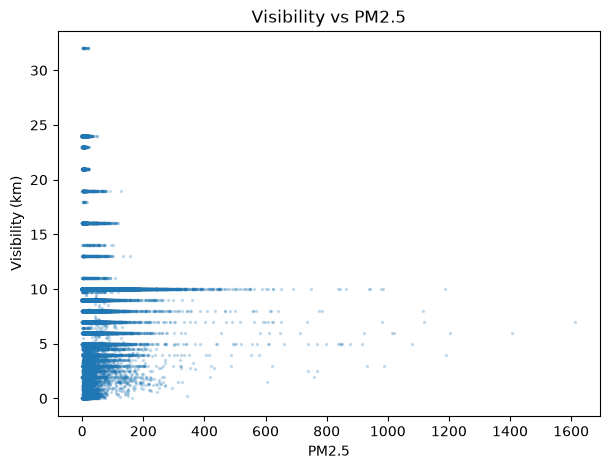

In [78]:
plt.figure(figsize=(7,5))

plt.scatter(
    df["air_quality_PM2.5"],
    df["visibility_km"],
    s=2,
    alpha=0.2
)

plt.xlabel("PM2.5")
plt.ylabel("Visibility (km)")

plt.title("Visibility vs PM2.5")

plt.show()